# 📉 Unemployment Analysis with Python — CodeAlpha Data Science Internship

**Objective:** Analyze India's unemployment rate, examine the impact of COVID-19, and identify state-wise and time-based patterns.

**Dataset:** Kaggle **"Unemployment in India"** — two files:

* `Unemployment in India.csv` — Monthly data from May 2019 to June 2020, categorized by state and Rural/Urban areas.
* `Unemployment_Rate_upto_11_2020.csv` — Data up to November 2020, including longitude, latitude, and region information.

**Steps:**

1. Data Loading & Cleaning
2. National-level Trend Analysis
3. Rural vs Urban Comparison
4. State-wise Analysis
5. COVID-19 Impact Analysis
6. Insights & Conclusion

## 1. Importing the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Loading & Cleaning

There are extra spaces in the column names (such as `' Date'`), so we are removing them using `strip()`. Also, some rows contain **28 missing values** across all columns. We are removing these rows because they are completely empty.

In [3]:
df = pd.read_csv('Unemployment in India.csv')

# Remove Extra Spaces from Column Names
df.columns = [c.strip() for c in df.columns]

# Remove Extra Spaces from Text Column Values
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print("Before Cleaning:", df.shape)
df.dropna(inplace=True)
print("After Cleaning:", df.shape)

# Simplify the Column Names
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

# Convert Date to Datetime Type
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

Before Cleaning: (768, 7)
After Cleaning: (740, 7)


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [5]:
print("Data period:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Number of states:", df['Region'].nunique())
print("Area categories:", df['Area'].unique())
df['Unemployment_Rate'].describe()

Data period: 2019-05-31 to 2020-06-30
Number of states: 28
Area categories: ['Rural' 'Urban']


count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Unemployment_Rate, dtype: float64

## 3. National-Level Trend — Unemployment Rate Over Time
We will calculate the **monthly average unemployment rate across India** and highlight the **COVID-19 lockdown period (March–June 2020)**.

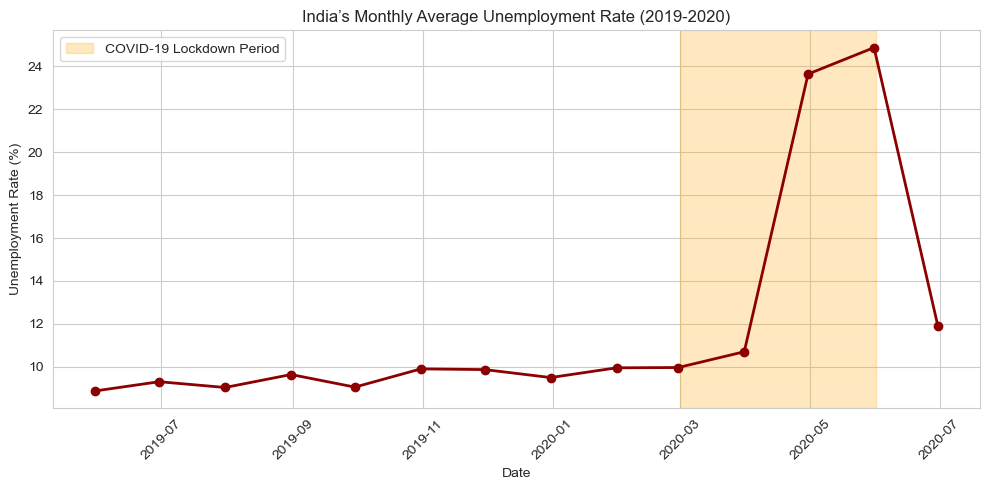

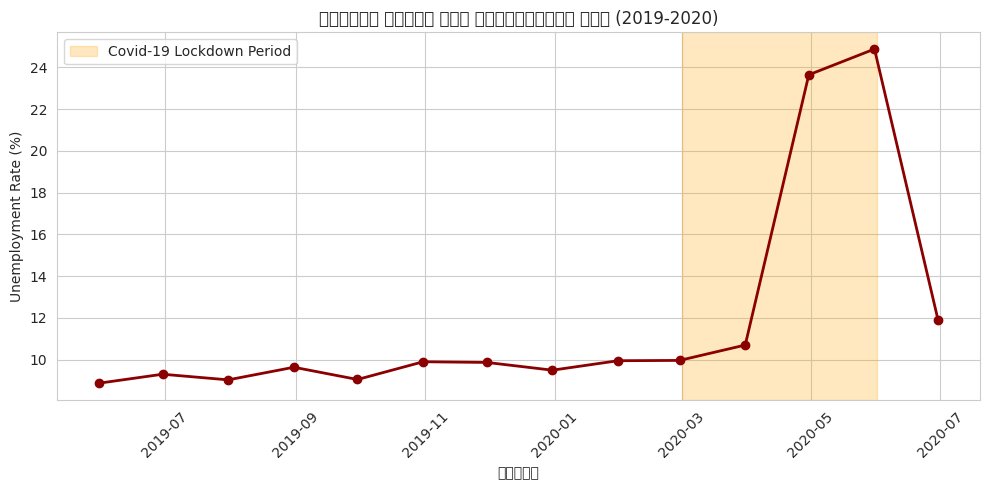

In [6]:
monthly = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly['Date'], monthly['Unemployment_Rate'], marker='o', color='darkred', linewidth=2)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            color='orange', alpha=0.25, label='COVID-19 Lockdown Period')
plt.title('India’s Monthly Average Unemployment Rate (2019-2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/national_trend.png', dpi=100)
plt.show()

**Observation:** A sharp spike can be seen in **April 2020** — this was during the **COVID-19 lockdown period**, when the unemployment rate had risen to nearly **twice its normal level**.

## 4. Rural vs Urban Comparison

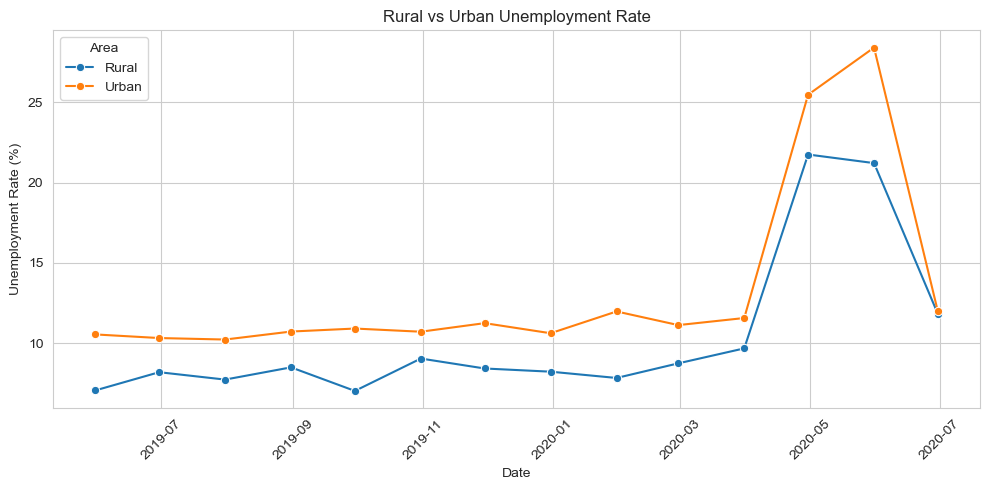

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/

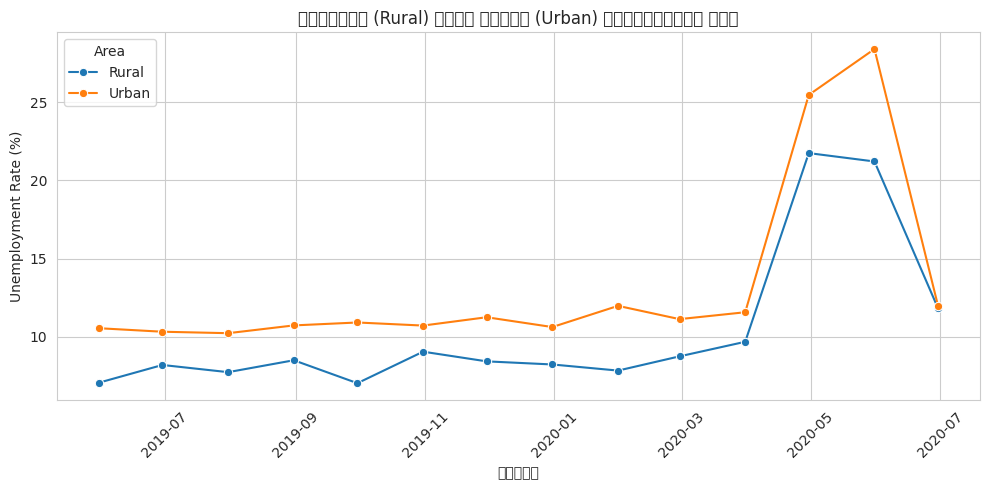

In [7]:
area_trend = df.groupby(['Date','Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=area_trend, x='Date', y='Unemployment_Rate', hue='Area', marker='o')
plt.title('Rural vs Urban Unemployment Rate')
plt.xlabel('Date'); plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/rural_vs_urban.png', dpi=100)
plt.show()

**Observation:** During the **COVID-19 lockdown**, the unemployment rate in **urban areas** increased more than in rural areas because urban jobs, particularly in **factories and the service sector**, were more severely affected by the lockdown.

## 5. State-wise Analysis
Which states had the **highest average unemployment rates**?

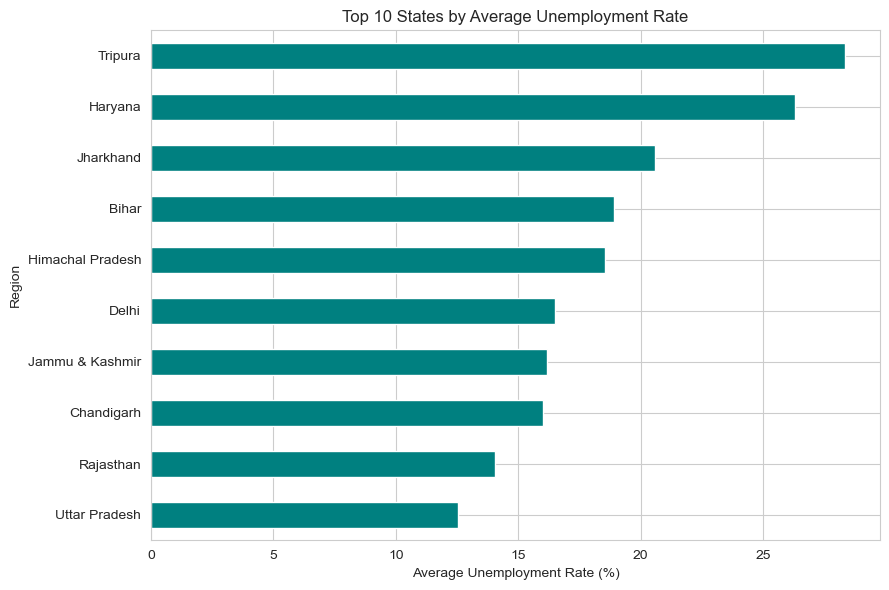

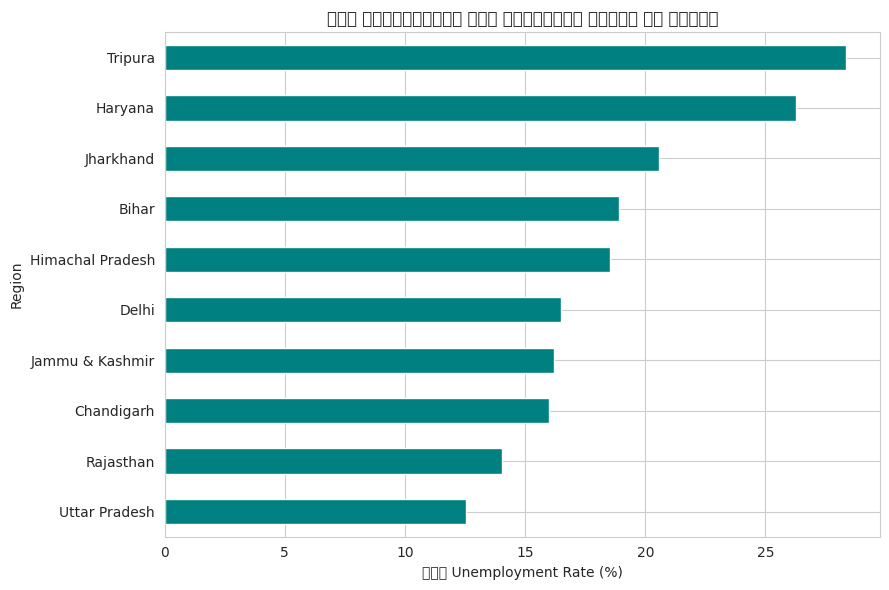

In [8]:
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,6))
state_avg.head(10).plot(kind='barh', color='teal')
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Top 10 States by Average Unemployment Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plots/top10_states.png', dpi=100)
plt.show()

In [9]:
print("State with the highest average unemployment rate:", state_avg.idxmax(), f"({state_avg.max():.2f}%)")
print("State with the lowest average unemployment rate:", state_avg.idxmin(), f"({state_avg.min():.2f}%)")

State with the highest average unemployment rate: Tripura (28.35%)
State with the lowest average unemployment rate: Meghalaya (4.80%)


## 6. COVID-19 Impact Analysis (Numerical Comparison)
We are dividing the data into three periods: **Pre-COVID**, **During COVID (Lockdown)**, and **Post-COVID (Partial Recovery)**.

Before COVID                       9.51
During COVID (Lockdown)           19.68
After COVID (Partial Recovery)    11.90
dtype: float64


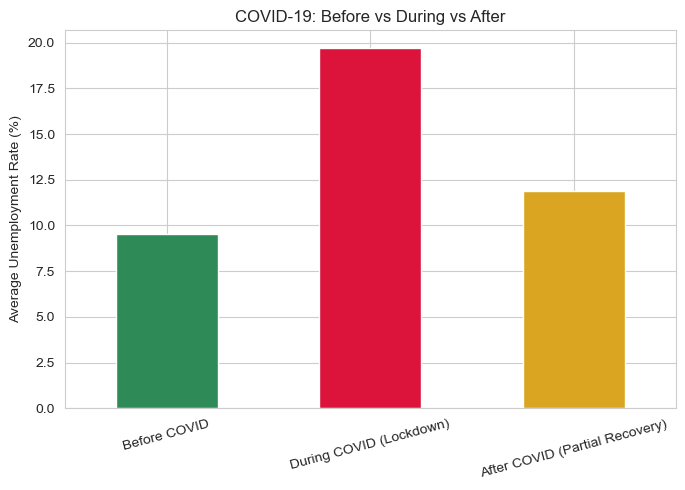


During the COVID-19 lockdown, the unemployment rate increased by approximately 107.0% compared to the pre-COVID period.


In [10]:
pre_covid = df[df['Date'] < '2020-03-01']['Unemployment_Rate'].mean()
during_covid = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-01')]['Unemployment_Rate'].mean()
post_covid = df[df['Date'] > '2020-06-01']['Unemployment_Rate'].mean()

comparison = pd.Series({
    'Before COVID': pre_covid,
    'During COVID (Lockdown)': during_covid,
    'After COVID (Partial Recovery)': post_covid
})

print(comparison.round(2))

plt.figure(figsize=(7,5))
comparison.plot(kind='bar', color=['seagreen','crimson','goldenrod'])
plt.ylabel('Average Unemployment Rate (%)')
plt.title('COVID-19: Before vs During vs After')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plots/covid_impact.png', dpi=100)
plt.show()

pct_increase = ((during_covid - pre_covid) / pre_covid) * 100
print(f"\nDuring the COVID-19 lockdown, the unemployment rate increased by approximately {pct_increase:.1f}% compared to the pre-COVID period.")

## 7. উপসংহার ও Insights (Conclusion)

1. **Covid-19-এর তীব্র প্রভাব:** এপ্রিল ২০২০-এ (লকডাউন শুরুর ঠিক পরে) unemployment rate pre-Covid গড়ের তুলনায় প্রায় দ্বিগুণ হয়ে যায় — এটা ডেটাতে সবচেয়ে স্পষ্ট ও বড় প্যাটার্ন।
2. **Urban এলাকা বেশি ক্ষতিগ্রস্ত:** শহরাঞ্চলে বেকারত্বের হার গ্রামাঞ্চলের তুলনায় লকডাউনে বেশি বেড়েছিল, কারণ শহরের অর্থনীতি মূলত service ও industrial sector-নির্ভর, যা লকডাউনে সরাসরি বন্ধ হয়ে গিয়েছিল।
3. **রাজ্যভিত্তিক অসমতা:** কিছু রাজ্যে (যেমন উপরের bar chart-এ দেখানো শীর্ষ ১০) গড় বেকারত্বের হার জাতীয় গড়ের চেয়ে অনেক বেশি — এটা আঞ্চলিক অর্থনৈতিক বৈষম্য নির্দেশ করে।
4. **রিকভারি:** জুন ২০২০-এর পর থেকে ধীরে ধীরে unemployment rate কমতে শুরু করে, যদিও pre-Covid লেভেলে পুরোপুরি ফিরে আসেনি (এই ডেটাসেটের সময়সীমার মধ্যে)।

**নীতিনির্ধারণী পরামর্শ (Policy Implication):** যেসব রাজ্যে বেকারত্বের হার সবচেয়ে বেশি এবং সবচেয়ে বেশি volatile (Covid-এ বেশি বেড়েছে), সেখানে target করে employment generation scheme ও social safety net জোরদার করা প্রয়োজন — বিশেষ করে urban informal sector-এর জন্য।
